### **Imports & Configurations**


In [1]:
import warnings
from typing import List, Tuple

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, classification_report, mean_absolute_error

# ==========================================
# Configurations & Display Settings
# ==========================================
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

TICKER: str = "AAPL"
FORECAST_DAYS: int = 5

FEATURE_COLS: List[str] = [
    "Open", "High", "Low", "Close", "Volume",
    "Daily_Range", "Intraday_Return", "Overnight_Gap",
    "Close_to_10d_High", "Close_to_10d_Low",
    "RSI_14", "MACD", "MACD_Signal", "MACD_Histogram",
]

### **Data Ingestion**


In [2]:
def fetch_historical_data(ticker_symbol: str, period: str = "3y") -> pd.DataFrame:
    """Fetch historical daily data from yfinance."""
    print(f"Fetching {period} of historical data for {ticker_symbol}...")
    ticker = yf.Ticker(ticker_symbol)
    df = ticker.history(period=period)

    if df.empty:
        raise ValueError(f"No data returned for ticker '{ticker_symbol}'")
    return df


raw_data = fetch_historical_data(TICKER, period="3y")
raw_data.tail(3)

Fetching 3y of historical data for AAPL...


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-04-09 00:00:00-04:00,259.000000,261.119995,256.070007,260.489990,28121600,0.0,0.0
2026-04-10 00:00:00-04:00,259.980011,262.190002,259.019989,260.480011,31259500,0.0,0.0
2026-04-13 00:00:00-04:00,259.859985,260.179993,256.660004,258.029999,19294169,0.0,0.0


### **Feature & Target Engineering**


In [3]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Generate technical indicators and derived features using vectorized operations."""
    data = df.copy()

    # Basic price features
    data["Daily_Range"] = data["High"] - data["Low"]
    data["Intraday_Return"] = (data["Close"] - data["Open"]) / data["Open"]

    prev_close = data["Close"].shift(1)
    data["Overnight_Gap"] = np.where(
        prev_close.notna(),
        (data["Open"] - prev_close) / prev_close,
        0,
    )

    # Rolling metrics
    rolling_high = data["High"].rolling(window=10).max()
    rolling_low = data["Low"].rolling(window=10).min()

    data["Close_to_10d_High"] = data["Close"] / rolling_high
    data["Close_to_10d_Low"] = data["Close"] / rolling_low

    # RSI (14)
    delta = data["Close"].diff()
    gain = delta.clip(lower=0).ewm(com=13, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(com=13, adjust=False).mean()

    rs = np.divide(gain, loss, out=np.zeros_like(gain), where=loss != 0)
    data["RSI_14"] = 100 - (100 / (1 + rs))

    # MACD
    ema12 = data["Close"].ewm(span=12, adjust=False).mean()
    ema26 = data["Close"].ewm(span=26, adjust=False).mean()

    data["MACD"] = ema12 - ema26
    data["MACD_Signal"] = data["MACD"].ewm(span=9, adjust=False).mean()
    data["MACD_Histogram"] = data["MACD"] - data["MACD_Signal"]

    return data.dropna()


def build_unified_targets(df: pd.DataFrame, days: int = FORECAST_DAYS) -> Tuple[pd.DataFrame, str, List[str]]:
    """Create targets for both the Classifier (1-day direction) and Regressor (multi-day returns)."""
    data = df.copy()

    # 1. Classifier Target (1 if tomorrow's close > today's close, else 0)
    class_target: str = "Target_Class"
    data[class_target] = (data["Close"].shift(-1) > data["Close"]).astype(int)

    # 2. Regressor Targets (Percentage returns for the next N days)
    reg_targets: List[str] = []
    for i in range(1, days + 1):
        col = f"Return_{i}d"
        data[col] = (data["Close"].shift(-i) - data["Close"]) / data["Close"]
        reg_targets.append(col)

    return data, class_target, reg_targets


# Apply transformations
processed_features = engineer_features(raw_data)
processed_data, CLASS_TARGET, REG_TARGETS = build_unified_targets(
    processed_features, days=FORECAST_DAYS)

# Drop rows where future targets are unknown (the last 5 days of the dataset)
processed_data = processed_data.dropna(subset=REG_TARGETS)

### **Unified Training & Evaluation Engine**


In [4]:
# ==========================================
# Model Architecture
# ==========================================
class StockLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, output_size: int):
        super(StockLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, time_steps, features)
        out, _ = self.lstm(x)
        # Take the output from the last time step
        out = out[:, -1, :]
        out = self.fc(out)
        return out


class LSTMModelWrapper:
    """Wrapper to make PyTorch look like a Scikit-Learn estimator for your workflow."""

    def __init__(self, is_classifier: bool, output_size: int):
        self.is_classifier = is_classifier
        self.output_size = output_size
        self.scaler = StandardScaler()
        self.model = None
        self.feature_importances_ = None

    def fit(self, X, y):
        # 1. Scale data
        X_scaled = self.scaler.fit_transform(X)
        # 2. Reshape for LSTM (samples, 1 time_step, features)
        X_seq = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

        X_tensor = torch.tensor(X_seq, dtype=torch.float32)
        y_tensor = torch.tensor(y.values, dtype=torch.float32)
        if self.is_classifier:
            y_tensor = y_tensor.view(-1, 1)

        dataset = TensorDataset(X_tensor, y_tensor)
        dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

        # 3. Initialize Model
        self.model = StockLSTM(input_size=len(
            FEATURE_COLS), hidden_size=50, output_size=self.output_size)
        criterion = nn.BCEWithLogitsLoss() if self.is_classifier else nn.MSELoss()
        optimizer = optim.Adam(self.model.parameters(), lr=0.001)

        # 4. Training Loop
        self.model.train()
        for epoch in range(50):
            for batch_X, batch_y in dataloader:
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

        # Approximate feature importance using absolute weights of the input layer
        with torch.no_grad():
            weights = torch.abs(
                self.model.lstm.weight_ih_l0).sum(dim=0).numpy()
            self.feature_importances_ = weights / weights.sum()

    def predict(self, X):
        self.model.eval()
        X_scaled = self.scaler.transform(X)
        X_seq = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))
        X_tensor = torch.tensor(X_seq, dtype=torch.float32)

        with torch.no_grad():
            outputs = self.model(X_tensor)
            if self.is_classifier:
                # Return class labels (0 or 1)
                return (torch.sigmoid(outputs) > 0.5).int().numpy().flatten()
            return outputs.numpy()


def train_and_evaluate_models(
    data: pd.DataFrame,
    features: List[str],
    class_target: str,
    reg_targets: List[str]
) -> Tuple[LSTMModelWrapper, LSTMModelWrapper]:
    """Chronologically splits data, trains LSTM models, and prints diagnostics."""

    train_size = int(len(data) * 0.8)
    train_data = data.iloc[:train_size]
    test_data = data.iloc[train_size:]

    X_train, X_test = train_data[features], test_data[features]
    y_train_class, y_test_class = train_data[class_target], test_data[class_target]
    y_train_reg, y_test_reg = train_data[reg_targets], test_data[reg_targets]

    print(
        f"Dataset Split: Training on {len(X_train)} days, Testing on {len(X_test)} days.\n")

    # MODEL 1: CLASSIFIER
    print("="*60)
    print(" 📈 MODEL 1: LSTM CLASSIFIER (Direction Prediction)")
    print("="*60)
    clf_model = LSTMModelWrapper(is_classifier=True, output_size=1)
    clf_model.fit(X_train, y_train_class)
    test_preds_class = clf_model.predict(X_test)

    print(
        f"Training Accuracy: {accuracy_score(y_train_class, clf_model.predict(X_train)):.2%}")
    print(
        f"Test Accuracy:     {accuracy_score(y_test_class, test_preds_class):.2%}")
    print("\nClassification Report:")
    print(classification_report(y_test_class, test_preds_class,
          target_names=['Down (0)', 'Up (1)']))

    # MODEL 2: REGRESSOR
    print("\n" + "="*60)
    print(" 📉 MODEL 2: LSTM REGRESSOR (5-Day Return Forecast)")
    print("="*60)
    reg_model = LSTMModelWrapper(
        is_classifier=False, output_size=len(reg_targets))
    reg_model.fit(X_train, y_train_reg)
    test_preds_reg = reg_model.predict(X_test)

    print(
        f"Training MAE: {mean_absolute_error(y_train_reg, reg_model.predict(X_train)):.4f}")
    print(
        f"Test MAE:     {mean_absolute_error(y_test_reg, test_preds_reg):.4f}")

    sample_actual = y_test_reg.iloc[-1].values
    sample_pred = test_preds_reg[-1]

    print("\nSample Forecast Verification (Last Day of Test Set):")
    for i in range(len(sample_actual)):
        print(
            f" Day {i+1} Ahead -> AI Predicted Return: {sample_pred[i]:>6.2%} | Actual: {sample_actual[i]:>6.2%}")

    return clf_model, reg_model

### **Execution**


In [5]:
# Execute the pipeline and extract the trained models
classifier, regressor = train_and_evaluate_models(
    processed_data,
    FEATURE_COLS,
    CLASS_TARGET,
    REG_TARGETS
)

Dataset Split: Training on 590 days, Testing on 148 days.

 📈 MODEL 1: LSTM CLASSIFIER (Direction Prediction)
Training Accuracy: 60.51%
Test Accuracy:     51.35%

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.49      0.63      0.55        70
      Up (1)       0.55      0.41      0.47        78

    accuracy                           0.51       148
   macro avg       0.52      0.52      0.51       148
weighted avg       0.52      0.51      0.51       148


 📉 MODEL 2: LSTM REGRESSOR (5-Day Return Forecast)
Training MAE: 0.0177
Test MAE:     0.0367

Sample Forecast Verification (Last Day of Test Set):
 Day 1 Ahead -> AI Predicted Return:  0.23% | Actual: -2.07%
 Day 2 Ahead -> AI Predicted Return:  0.39% | Actual:  0.02%
 Day 3 Ahead -> AI Predicted Return: -0.09% | Actual:  0.63%
 Day 4 Ahead -> AI Predicted Return: -1.60% | Actual:  0.63%
 Day 5 Ahead -> AI Predicted Return: -1.75% | Actual: -0.32%


### **Visualizing the AI's Logic**


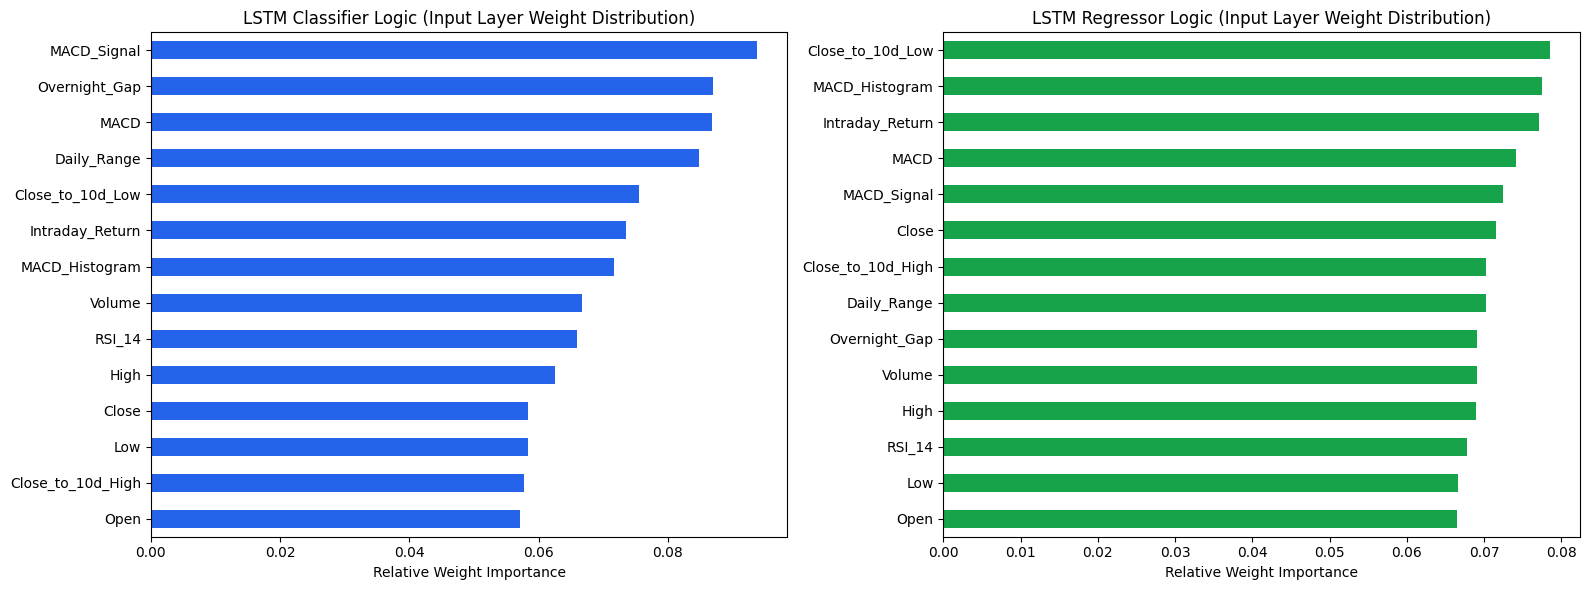

In [6]:
# Extract importances (Calculated from LSTM input gate weights)
clf_importances = pd.Series(
    classifier.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
reg_importances = pd.Series(
    regressor.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

# Plot side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

clf_importances.plot.barh(ax=axes[0], color='#2563eb')  # Blue
axes[0].set_title(
    "LSTM Classifier Logic (Input Layer Weight Distribution)", fontsize=12)
axes[0].set_xlabel("Relative Weight Importance")

reg_importances.plot.barh(ax=axes[1], color='#16a34a')  # Green
axes[1].set_title(
    f"LSTM Regressor Logic (Input Layer Weight Distribution)", fontsize=12)
axes[1].set_xlabel("Relative Weight Importance")

fig.tight_layout()
plt.show()